## Random Forest Classification on Multi-class Sentiment Dataset.
## Tools: Python, scikit-learn, pandas, matplotlib.

In [ ]:
# Importing Libraries.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Load the dataset.
df = pd.read_csv("/content/3) Sentiment dataset.csv")
df.head()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.1  732 non-null    int64  
 1   Unnamed: 0    732 non-null    int64  
 2   Text          732 non-null    object 
 3   Sentiment     732 non-null    object 
 4   Timestamp     732 non-null    object 
 5   User          732 non-null    object 
 6   Platform      732 non-null    object 
 7   Hashtags      732 non-null    object 
 8   Retweets      732 non-null    float64
 9   Likes         732 non-null    float64
 10  Country       732 non-null    object 
 11  Year          732 non-null    int64  
 12  Month         732 non-null    int64  
 13  Day           732 non-null    int64  
 14  Hour          732 non-null    int64  
dtypes: float64(2), int64(6), object(7)
memory usage: 85.9+ KB


In [ ]:
df.describe()

,Unnamed: 0.1,Unnamed: 0,Retweets,Likes,Year,Month,Day,Hour
count,732.000000,732.000000,732.000000,732.000000,732.000000,732.000000,732.000000,732.000000
mean,366.464481,369.740437,21.508197,42.901639,2020.471311,6.122951,15.497268,15.521858
std,211.513936,212.428936,7.061286,14.089848,2.802285,3.411763,8.474553,4.113414
min,0.000000,0.000000,5.000000,10.000000,2010.000000,1.000000,1.000000,0.000000
25%,183.750000,185.750000,17.750000,34.750000,2019.000000,3.000000,9.000000,13.000000
50%,366.500000,370.500000,22.000000,43.000000,2021.000000,6.000000,15.000000,16.000000
75%,549.250000,553.250000,25.000000,50.000000,2023.000000,9.000000,22.000000,19.000000
max,732.000000,736.000000,40.000000,80.000000,2023.000000,12.000000,31.000000,23.000000


In [ ]:
df.isnull().sum()

,0
Unnamed: 0.1,0
Unnamed: 0,0
Text,0
Sentiment,0
Timestamp,0
User,0
Platform,0
Hashtags,0
Retweets,0
Likes,0


In [ ]:
# Drop missing values.
df = df.dropna(subset=["Text", "Sentiment"])

### Random Forest Classifier.

In [ ]:
# Libraries for Random Forest Classifier.
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [ ]:
# 1. Features and target.
X = df["Text"]
y = df["Sentiment"]

In [ ]:
# 2. Train/test split.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
print(y.value_counts())

Sentiment
Positive               44
Joy                    42
Excitement             32
Happy                  14
Neutral                14
                       ..
Vibrancy                1
Culinary Adventure      1
Mesmerizing             1
Thrilling Journey       1
Winter Magic            1
Name: count, Length: 279, dtype: int64


In [ ]:
# 3. Build pipeline: TF-IDF + RandomForest.
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english")),
    ("rf", RandomForestClassifier(random_state=42))
])

In [ ]:
# 4. Hyperparameter grid.
param_grid = {
    "rf__n_estimators": [100, 200, 300],
    "rf__max_depth": [None, 10, 20, 50],
    "rf__min_samples_split": [2, 5, 10],
    "rf__min_samples_leaf": [1, 2, 4]
}

In [ ]:
# 5. Stratified cross-validation.
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv_strategy,
    n_jobs=-1,
    verbose=2,
    scoring="f1_macro"
)

In [ ]:
# 6. Train model.
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 108 candidates, totalling 324 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


GridSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('tfidf',
                                        TfidfVectorizer(stop_words='english')),
                                       ('rf',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'rf__max_depth': [None, 10, 20, 50],
                         'rf__min_samples_leaf': [1, 2, 4],
                         'rf__min_samples_split': [2, 5, 10],
                         'rf__n_estimators': [100, 200, 300]},
             scoring='f1_macro', verbose=2)

In [ ]:
# 7. Best parameters.
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'rf__max_depth': None, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 10, 'rf__n_estimators': 300}


In [ ]:
# 8. Evaluate on test set.
y_pred = grid_search.predict(X_test)
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
                         precision    recall  f1-score   support

         Acceptance          0.00      0.00      0.00         2
      Acceptance             0.00      0.00      0.00         0
           Admiration        0.00      0.00      0.00         1
        Admiration           0.00      0.00      0.00         1
         Affection           0.00      0.00      0.00         1
      Ambivalence            1.00      1.00      1.00         1
         Anger               0.00      0.00      0.00         1
        Anticipation         0.00      0.00      0.00         1
        Arousal              0.67      0.67      0.67         3
        ArtisticBurst        0.00      0.00      0.00         0
                  Awe        0.00      0.00      0.00         1
               Awe           0.00      0.00      0.00         0
         Awe                 0.00      0.00      0.00         1
                  Bad        1.00      1.00      1.00         1
             B

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

## Features Importance Analysis.

In [ ]:
# Train.
pipeline.fit(X_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer(stop_words='english')),
                ('rf', RandomForestClassifier(random_state=42))])

In [ ]:
# Extract feature names.
feature_names = pipeline.named_steps["tfidf"].get_feature_names_out()

In [ ]:
# Feature Importances.
importances = pipeline.named_steps["rf"].feature_importances_

In [ ]:
# Sort and display top features.
import numpy as np

# Sort by importance.
indices = np.argsort(importances)[::-1]

# Show top 20 features.
top_n = 20
for i in range(top_n):
    print(f"{feature_names[indices[i]]}: {importances[indices[i]]:.4f}")

new: 0.0125
gratitude: 0.0089
contentment: 0.0076
hopeful: 0.0073
despair: 0.0073
serenity: 0.0072
loneliness: 0.0062
determination: 0.0062
day: 0.0054
accidentally: 0.0052
euphoria: 0.0050
bitterness: 0.0049
feeling: 0.0047
grief: 0.0047
bad: 0.0046
pride: 0.0045
enthusiasm: 0.0045
jealousy: 0.0042
nostalgia: 0.0042
inspiration: 0.0040


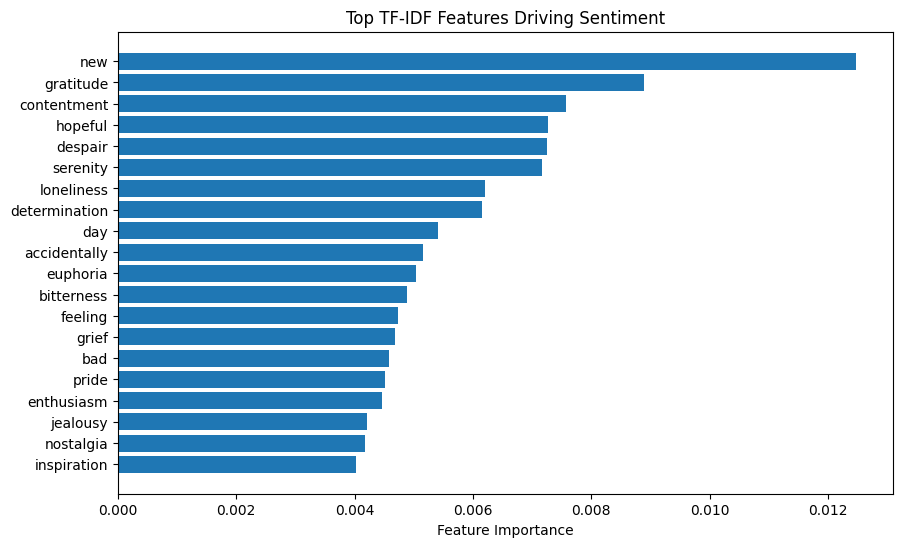

In [ ]:
# Visualize top features.
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(range(top_n), importances[indices[:top_n]][::-1], align="center")
plt.yticks(range(top_n), feature_names[indices[:top_n]][::-1])
plt.xlabel("Feature Importance")
plt.title("Top TF-IDF Features Driving Sentiment")
plt.show()

### - Collect feature importances from the trained Random Forest (feature_importances_).
- Sort them in descending order to identify the most influential words/tokens.
- Select the top N features (e.g., top 20) for clarity.
- Plot a horizontal bar chart with matplotlib showing importance scores.
- Label bars with feature names (words/hashtags) for easy interpretation.
- Use the chart to quickly see which terms drive sentiment predictions most strongly.


Here’s a concise six‑line highlight of the whole process:
- Load and clean the dataset to ensure text and sentiment labels are usable.
- Convert text into numerical features using TF‑IDF vectorization.
- Split data into training and testing sets for model evaluation.
- Train a Random Forest classifier to learn sentiment patterns.
- Tune hyperparameters with GridSearchCV (trees, depth, splits, leaves) for best performance.
- Evaluate with accuracy, precision, recall, and F1‑score and analyze feature importance for insights.
